<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  24/11/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-1</strong></p>
</div>

---

# **🧠 PROYECTO: Análisis y Predicción de la Cintilación Ionosférica (Índice S4)**

- Tema: Aplicación de técnicas de aprendizaje profundo (LSTM) para la predicción del índice S4 a partir de parámetros ionosféricos y geomagnéticos.

# **📦 1. Importación y carga de datos**

In [65]:
# =====================================
# 1. Importar librerías necesarias
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import os

# **📂 2. Lectura y exploración inicial del dataset**

In [67]:
# =====================================
# 2. Cargar el dataset base
# =====================================
print(os.getcwd())
#df = pd.read_csv("../data/df_FINAL.csv")
df = pd.read_csv("df_FINAL.csv")

# Convertir columna de tiempo a formato datetime
df["Tiempo"] = pd.to_datetime(df["Tiempo"])

# Mostrar información general
print(df.info())
print(df.head())

/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204396 entries, 0 to 204395
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Tiempo       204396 non-null  datetime64[ns]
 1   Cintilacion  204396 non-null  float64       
 2   Azimuth      204396 non-null  float64       
 3   Elevacion    204396 non-null  float64       
 4   TEC          204396 non-null  float64       
 5   ROTEC        204396 non-null  float64       
 6   ROTI         204396 non-null  float64       
 7   Kp_Index     204396 non-null  float64       
 8   Dst_Index    204396 non-null  float64       
 9   ap_Index     204396 non-null  float64       
 10  f10.7_Index  204396 non-null  float64       
 11  AE_Index     204396 non-null  float64       
 12  S4           204396 non-null  float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 20.3 MB
None
         

# **📅 3. Detección de días con presencia de cintilación**

In [37]:
# =====================================
# 3. Identificar días con cintilación
# =====================================

# Extraer solo la fecha
df["dias"] = df["Tiempo"].dt.date

# Número total de días en el dataset
print(f"Número total de días: {df['dias'].nunique()}")

# Filtrar días donde hubo cintilación (Cintilacion == 1)
df_con_cintilacion = df[df['Cintilacion'] == 1].copy()
df_con_cintilacion["Fecha"] = df_con_cintilacion["Tiempo"].dt.date

# Contar días únicos con cintilación
dias_unicos = pd.Series(df_con_cintilacion["Fecha"].unique())
print(f"Número de días con cintilación: {dias_unicos.nunique()}")

Número total de días: 148
Número de días con cintilación: 29


In [7]:
# =====================================
# 4. Crear dataset solo con días de cintilación
# =====================================

# Releer dataset completo
df_FINAL = pd.read_csv("df_FINAL.csv")
df_FINAL["Tiempo"] = pd.to_datetime(df_FINAL["Tiempo"])

# Establecer índice temporal
df_new = df_FINAL.set_index("Tiempo").copy()

# Convertir fechas únicas a formato datetime
dias_unicos = pd.to_datetime(dias_unicos)

# Filtrar registros correspondientes a los días con cintilación
df_FINAL_CINT = df_new[df_new.index.normalize().isin(dias_unicos)].reset_index()

print(f"Filas finales con cintilación: {len(df_FINAL_CINT)}")


Filas finales con cintilación: 40838


In [71]:
dias_unicos = pd.Series(df_con_cintilacion["Fecha"].unique())
dias_unicos

0     2025-01-28
1     2025-01-30
2     2025-01-31
3     2025-02-01
4     2025-02-04
5     2025-02-05
6     2025-02-06
7     2025-02-07
8     2025-02-08
9     2025-02-09
10    2025-02-11
11    2025-02-12
12    2025-02-13
13    2025-02-14
14    2025-02-21
15    2025-02-25
16    2025-02-26
17    2025-03-06
18    2025-03-07
19    2025-03-08
20    2025-03-12
21    2025-03-13
22    2025-03-14
23    2025-03-16
24    2025-03-18
25    2025-03-22
26    2025-03-30
27    2025-04-02
28    2025-04-03
dtype: object

# **🧮 4. Filtrado del dataset por días con cintilación**

In [73]:
df_FINAL_CINT.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
0,2025-01-28 00:01:00,0.0,140.0,52.0,71.649570,-0.006873,0.010323,20.0,-0.016667,7.0,166.3,97.8,0.093
1,2025-01-28 00:02:00,0.0,226.0,43.0,71.544307,-0.006454,0.010285,20.0,-0.033333,7.0,166.3,98.6,0.080
2,2025-01-28 00:03:00,0.0,227.0,44.0,71.439044,-0.006034,0.010248,20.0,-0.050000,7.0,166.3,99.4,0.122
3,2025-01-28 00:04:00,0.0,138.0,53.0,71.333781,-0.005614,0.010211,20.0,-0.066667,7.0,166.3,100.2,0.080
4,2025-01-28 00:05:00,0.0,137.0,54.0,71.228518,-0.005194,0.010174,20.0,-0.083333,7.0,166.3,101.0,0.086


# **📊 5. Visualización interactiva de TEC y ROTI**

El siguiente bloque genera gráficos dinámicos por día de observación con cintilación, usando Plotly.

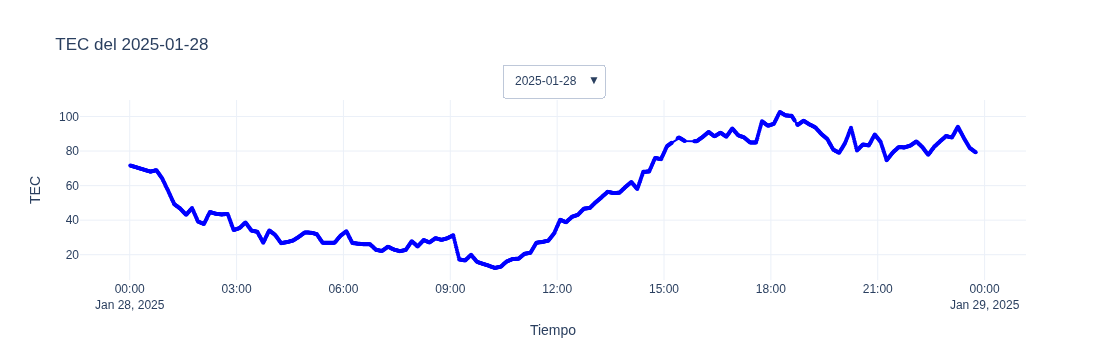

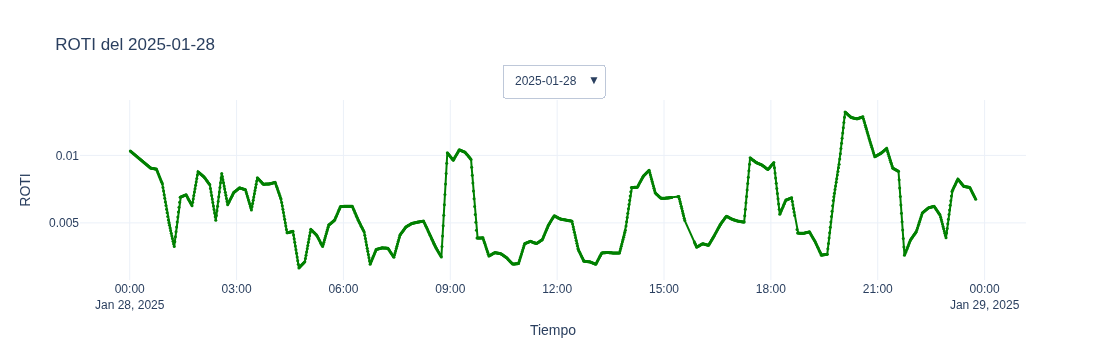

In [9]:
# =====================================
# 5. Visualización interactiva de TEC y ROTI
# =====================================

df = df_FINAL_CINT.copy()
df["Fecha"] = df["Tiempo"].dt.date
fechas_unicas = sorted(df["Fecha"].unique())
n_fechas = len(fechas_unicas)

trazas_tec, trazas_roti = [], []
botones_fechas_tec, botones_fechas_roti = [], []

for i, fecha in enumerate(fechas_unicas):
    inicio = pd.to_datetime(fecha)
    fin = inicio + timedelta(days=1)
    df_dia = df[(df["Tiempo"] >= inicio) & (df["Tiempo"] < fin)]

    # --- TEC ---
    trazas_tec.append(go.Scatter(
        x=df_dia["Tiempo"], y=df_dia["TEC"],
        mode="lines+markers",
        name=f"TEC - {fecha}",
        marker=dict(size=4, color="blue"),
        visible=(i == 0)
    ))

    # --- ROTI ---
    trazas_roti.append(go.Scatter(
        x=df_dia["Tiempo"], y=df_dia["ROTI"],
        mode="lines+markers",
        name=f"ROTI - {fecha}",
        marker=dict(size=3, color="green"),
        visible=(i == 0)
    ))

    # Botones de selección
    vis_tec = [False] * n_fechas
    vis_roti = [False] * n_fechas
    vis_tec[i] = True
    vis_roti[i] = True

    botones_fechas_tec.append(dict(
        label=str(fecha),
        method="update",
        args=[{"visible": vis_tec}, {"title": f"TEC del {fecha}"}]
    ))

    botones_fechas_roti.append(dict(
        label=str(fecha),
        method="update",
        args=[{"visible": vis_roti}, {"title": f"ROTI del {fecha}"}]
    ))

# --- Figura TEC ---
fig_tec = go.Figure(data=trazas_tec)
fig_tec.update_layout(
    title=f"TEC del {fechas_unicas[0]}",
    xaxis_title="Tiempo", yaxis_title="TEC",
    template="plotly_white",
    updatemenus=[dict(buttons=botones_fechas_tec, direction="down", showactive=True, x=0.5, y=1.2, xanchor="center", yanchor="top")],
    height=400
)

# --- Figura ROTI ---
fig_roti = go.Figure(data=trazas_roti)
fig_roti.update_layout(
    title=f"ROTI del {fechas_unicas[0]}",
    xaxis_title="Tiempo", yaxis_title="ROTI",
    template="plotly_white",
    updatemenus=[dict(buttons=botones_fechas_roti, direction="down", showactive=True, x=0.5, y=1.2, xanchor="center", yanchor="top")],
    height=400
)

fig_tec.show()
fig_roti.show()

# **🤖 6. Modelado predictivo del índice S4 (LSTM)**

In [77]:
df_FINAL_CINT.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
0,2025-01-28 00:01:00,0.0,140.0,52.0,71.649570,-0.006873,0.010323,20.0,-0.016667,7.0,166.3,97.8,0.093
1,2025-01-28 00:02:00,0.0,226.0,43.0,71.544307,-0.006454,0.010285,20.0,-0.033333,7.0,166.3,98.6,0.080
2,2025-01-28 00:03:00,0.0,227.0,44.0,71.439044,-0.006034,0.010248,20.0,-0.050000,7.0,166.3,99.4,0.122
3,2025-01-28 00:04:00,0.0,138.0,53.0,71.333781,-0.005614,0.010211,20.0,-0.066667,7.0,166.3,100.2,0.080
4,2025-01-28 00:05:00,0.0,137.0,54.0,71.228518,-0.005194,0.010174,20.0,-0.083333,7.0,166.3,101.0,0.086


In [90]:
df_FINAL_CINT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40838 entries, 0 to 40837
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Tiempo       40838 non-null  datetime64[ns]
 1   Cintilacion  40838 non-null  float64       
 2   Azimuth      40838 non-null  float64       
 3   Elevacion    40838 non-null  float64       
 4   TEC          40838 non-null  float64       
 5   ROTEC        40838 non-null  float64       
 6   ROTI         40838 non-null  float64       
 7   Kp_Index     40838 non-null  float64       
 8   Dst_Index    40838 non-null  float64       
 9   ap_Index     40838 non-null  float64       
 10  f10.7_Index  40838 non-null  float64       
 11  AE_Index     40838 non-null  float64       
 12  S4           40838 non-null  float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 4.1 MB


In [79]:
# =====================================
# 6. Preparar datos para el modelo LSTM
# =====================================

data = df_FINAL_CINT[["Tiempo", "S4"]].copy()
data = data[:88460]

data.set_index("Tiempo", inplace=True)

# Normalización de la serie S4
scaler = MinMaxScaler()
data["S4_SCALED"] = scaler.fit_transform(data[["S4"]])

# Crear secuencias supervisadas (n_steps -> horizonte futuro)
def create_sequences(data, n_steps, horizon, index=None):
    X, y, times = [], [], []
    for i in range(len(data) - n_steps - horizon):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps+horizon])
        if index is not None:
            times.append(index[i+n_steps+horizon])
    return np.array(X), np.array(y), np.array(times)

n_steps = 10   # Pasos hacia atrás
horizon = 5    # Horizonte de predicción
X, y, times = create_sequences(data["S4_SCALED"].values, n_steps, horizon, data.index)

# Dividir entrenamiento/prueba
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Ajustar dimensiones
#X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
#X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [81]:
X_train.shape

(32658, 10)

In [83]:
X_test.shape

(8165, 10)

# **🧬 7. Definición y entrenamiento del modelo LSTM**

In [85]:
# =====================================
# 7. Definir y entrenar modelo LSTM
# =====================================

model = Sequential([
    LSTM(50, activation="relu", input_shape=(n_steps, 1)),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")

history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/5


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



817/817 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 2/5
817/817 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0018 - val_loss: 0.0032
Epoch 3/5
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0018 - val_loss: 0.0031
Epoch 4/5
817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018 - val_loss: 0.0031
Epoch 5/5
817/817 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0018 - val_loss: 0.0032


# **🔍 8. Evaluación del modelo y visualización**

256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE : 0.0311
RMSE: 0.0537
MAPE: 0.1996


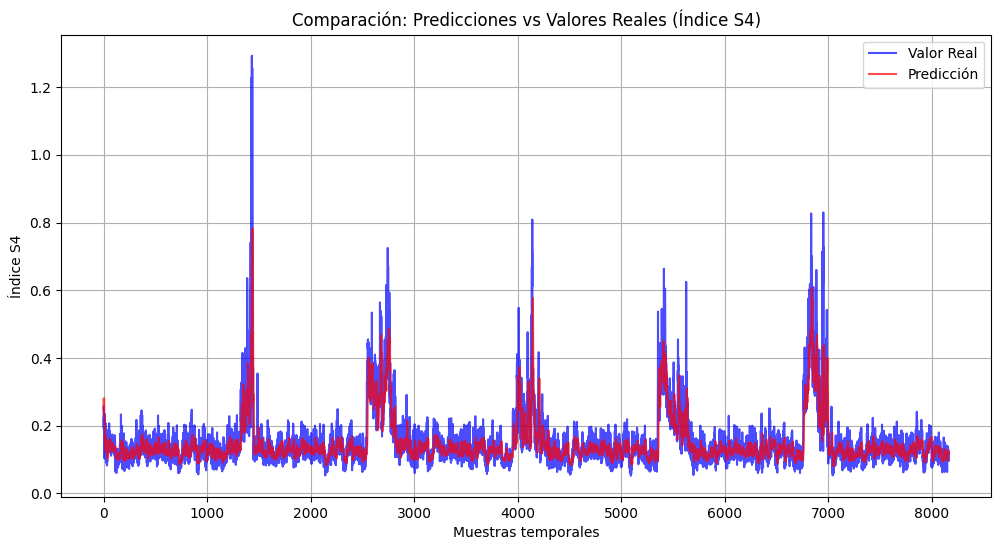

In [87]:
# =====================================
# 8. Predicción y evaluación
# =====================================

y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Métricas de rendimiento
mae  = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

# --- Visualización ---
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label="Valor Real", color="blue", alpha=0.7)
plt.plot(y_pred_inv, label="Predicción", color="red", alpha=0.7)
plt.title("Comparación: Predicciones vs Valores Reales (Índice S4)")
plt.xlabel("Muestras temporales")
plt.ylabel("Índice S4")
plt.legend()
plt.grid(True)
plt.show()


# **CODIGO MODULAR**

Ejecutando: ventana=120min, horizonte=30min ...
Epoch 1/10


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0039 - val_loss: 0.0052
Epoch 2/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0038 - val_loss: 0.0051
Epoch 3/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0037 - val_loss: 0.0050
Epoch 4/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0036 - val_loss: 0.0049
Epoch 5/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0036 - val_loss: 0.0054
Epoch 6/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0036 - val_loss: 0.0054
Epoch 7/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0035 - val_loss: 0.0049
Epoch 8/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0035 - val_loss: 0.0047
Epoch 9/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0035 - val_loss: 0.0047
Epoch 10/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0034 - val_loss: 0.0047
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ejecutando: ventana=180min, horizonte=60min ...
Epoch 1/10


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



889/889 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0052 - val_loss: 0.0070
Epoch 2/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0048 - val_loss: 0.0076
Epoch 3/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0049 - val_loss: 0.0070
Epoch 4/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0047 - val_loss: 0.0072
Epoch 5/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0046 - val_loss: 0.0067
Epoch 6/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0047 - val_loss: 0.0066
Epoch 7/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0046 - val_loss: 0.0069
Epoch 8/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0044 - val_loss: 0.0064
Epoch 9/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0045 - val_loss: 0.0067
Epoch 10/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0044 - val_loss: 0.0065
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ejecutando: ventana=60min, horizonte=20min ...
Epoch 1/10


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 2/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0031 - val_loss: 0.0040
Epoch 3/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0032 - val_loss: 0.0039
Epoch 4/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0031 - val_loss: 0.0038
Epoch 5/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0031 - val_loss: 0.0039
Epoch 6/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0031 - val_loss: 0.0036
Epoch 7/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0029 - val_loss: 0.0038
Epoch 8/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0031 - val_loss: 0.0037
Epoch 9/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0030 - val_loss: 0.0040
Epoch 10/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0030 - val_loss: 0.0037
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step
Ejecutando: ventana=60min, horizonte=30min ...
Epoch 1/10


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 2/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0039 - val_loss: 0.0049
Epoch 3/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0038 - val_loss: 0.0051
Epoch 4/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0037 - val_loss: 0.0051
Epoch 5/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0037 - val_loss: 0.0119
Epoch 6/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0038 - val_loss: 0.0046
Epoch 7/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0036 - val_loss: 0.0045
Epoch 8/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0036 - val_loss: 0.0048
Epoch 9/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0035 - val_loss: 0.0048
Epoch 10/10
892/892 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0034 - val_loss: 0.0046
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
   window_min  horizon_min  n_steps  horizon_steps       MAE      RMSE  \
0         120           30      120

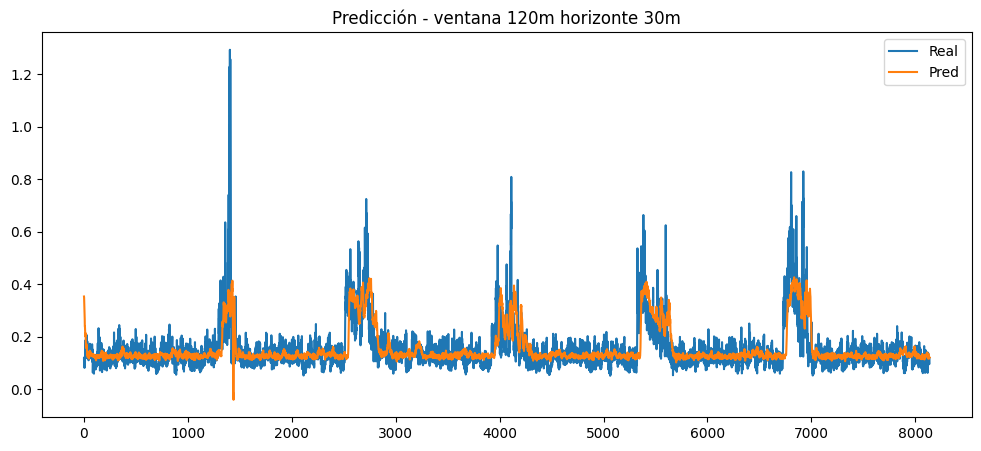

In [93]:
# ============================
# Librerías
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import time

# ============================
# Funciones utilitarias
# ============================
def minutes_to_steps(window_minutes: int, sampling_minutes: int) -> int:
    """Convierte ventana en minutos a número de pasos (samples)."""
    return int(window_minutes / sampling_minutes)

def minutes_to_horizon_steps(horizon_minutes: int, sampling_minutes: int) -> int:
    """Convierte horizonte en minutos a número de pasos (samples)."""
    return int(horizon_minutes / sampling_minutes)

def prepare_series(df, time_col='Tiempo', target_col='S4', sampling_minutes=1):
    """
    Recibe df con columna de tiempo y target, ordena, reindexa por tiempo continuo si se desea.
    Retorna serie con indice datetime y columna target.
    """
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col).set_index(time_col)
    # (Opcional) reindexar para asegurar muestreo continuo por minutos:
    # full_idx = pd.date_range(df.index.min(), df.index.max(), freq=f'{sampling_minutes}T')
    # df = df.reindex(full_idx).interpolate(method='time')  # si hay huecos usar interpolación
    series = df[[target_col]].dropna()
    return series

def create_sequences(series_values, n_steps, horizon_steps):
    """
    Crea X, y (sin times). series_values debe ser 1D numpy array.
    Retorna X [N, n_steps, 1], y [N,]
    """
    X, y = [], []
    for i in range(len(series_values) - n_steps - horizon_steps + 1):
        X.append(series_values[i:i+n_steps])
        y.append(series_values[i+n_steps+horizon_steps-1])  # -1 para que horizon=1 prediga el siguiente
    X = np.array(X)
    y = np.array(y)
    return X.reshape(X.shape[0], X.shape[1], 1), y

def build_lstm_model(n_steps, n_units=50):
    model = Sequential([
        LSTM(n_units, activation='tanh', input_shape=(n_steps, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test, n_steps,
                       epochs=50, batch_size=32, n_units=50, patience=5, verbose=0):
    """
    Entrena el modelo y devuelve (model, history, y_pred, metrics_dict)
    """
    model = build_lstm_model(n_steps, n_units)
    es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0)
    start = time.time()
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=verbose)
    train_time = time.time() - start
    y_pred = model.predict(X_test)
    return model, history, y_pred, train_time

def inverse_scale(scaler, arr):
    return scaler.inverse_transform(arr.reshape(-1,1)).ravel()

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# ============================
# Pipeline para una configuración
# ============================
def run_pipeline_for_config(df, window_minutes, horizon_minutes, sampling_minutes=1,
                            test_frac=0.2, val_frac=0.1, epochs=50, batch_size=32,
                            n_units=50, patience=5, verbose=0, target_col='S4'):
    """
    Ejecuta todo el pipeline para una ventana y horizonte (en minutos).
    Devuelve un dict con métricas y objetos (model, preds, history).
    """
    # 1) preparar serie
    series = prepare_series(df, time_col='Tiempo', target_col=target_col, sampling_minutes=sampling_minutes)
    values = series[target_col].values.reshape(-1,1)

    # 2) escalado
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values).ravel()

    # 3) pasos
    n_steps = minutes_to_steps(window_minutes, sampling_minutes)
    horizon_steps = minutes_to_horizon_steps(horizon_minutes, sampling_minutes)
    if n_steps < 1 or horizon_steps < 1:
        raise ValueError("n_steps o horizon_steps menor a 1. Ajusta window_minutes/sampling_minutes.")

    # 4) secuencias
    X, y = create_sequences(scaled, n_steps, horizon_steps)

    # 5) split train/val/test (por índice temporal: no shuffle)
    N = len(X)
    test_size = int(test_frac * N)
    val_size = int(val_frac * N)
    train_size = N - test_size - val_size
    if train_size < 10:
        raise ValueError("Pocos datos para entrenar: reduce test/val o aumenta ventana/horizonte.")

    X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
    y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

    # 6) entrenar
    model, history, y_pred_scaled, train_time = train_and_evaluate(
        X_train, y_train, X_val, y_val, X_test, y_test,
        n_steps=n_steps, epochs=epochs, batch_size=batch_size,
        n_units=n_units, patience=patience, verbose=verbose
    )

    # 7) inversa escala
    y_pred = inverse_scale(scaler, y_pred_scaled.ravel())
    y_test_inv = inverse_scale(scaler, y_test.ravel())

    # 8) métricas
    metrics = compute_metrics(y_test_inv, y_pred)
    metrics.update({'train_time_s': train_time, 'n_steps': n_steps, 'horizon_steps': horizon_steps,
                    'window_minutes': window_minutes, 'horizon_minutes': horizon_minutes})

    results = {
        'model': model,
        'history': history,
        'y_pred': y_pred,
        'y_test': y_test_inv,
        'metrics': metrics,
        'scaler': scaler,
        'X_test': X_test
    }
    return results

# ============================
# Función para comparar múltiples configuraciones
# ============================
def compare_configs(df, configs, sampling_minutes=1, **pipeline_kwargs):
    """
    configs: lista de tuples (window_minutes, horizon_minutes)
    Devuelve DataFrame con métricas para cada combinación y diccionario con resultados completos.
    """
    rows = []
    full_results = {}
    for (w, h) in configs:
        print(f"Ejecutando: ventana={w}min, horizonte={h}min ...")
        try:
            res = run_pipeline_for_config(df, w, h, sampling_minutes=sampling_minutes, **pipeline_kwargs)
            m = res['metrics']
            rows.append({
                'window_min': w, 'horizon_min': h,
                'n_steps': m['n_steps'], 'horizon_steps': m['horizon_steps'],
                'MAE': m['MAE'], 'RMSE': m['RMSE'], 'MAPE': m['MAPE'],
                'train_time_s': m['train_time_s']
            })
            full_results[(w,h)] = res
        except Exception as e:
            print(f"ERROR para (w={w}, h={h}): {e}")
            rows.append({'window_min': w, 'horizon_min': h, 'error': str(e)})
    return pd.DataFrame(rows), full_results

# ============================
# Ejemplo de uso (configurable)
# ============================
if __name__ == "__main__":
    # cargar tu df_FINAL 
    df_FINAL = pd.read_csv("df_FINAL.csv")  # O usar el df en memoria

    #--------------bloque de dias con cintilaciones-----
    df_FINAL["Tiempo"] = pd.to_datetime(df_FINAL["Tiempo"])
    
    # Establecer índice temporal
    df_new = df_FINAL.set_index("Tiempo").copy()
    
    # Convertir fechas únicas a formato datetime
    dias_unicos = pd.to_datetime(dias_unicos)
    
    # Filtrar registros correspondientes a los días con cintilación
    df_FINAL_CINT = df_new[df_new.index.normalize().isin(dias_unicos)].reset_index()

    df= df_FINAL_CINT.copy()
    #---------------------------------------------
    # configuraciones a probar:
    configs = [
        (120, 30),   # ventana 2h, horizonte 30min
        (180, 60),   # ventana 3h, horizonte 1h
        (60, 20),    # ventana 1h, horizonte 20min
        (60, 30),    # ventana 1h, horizonte 30min
    ]

    results_df, full_results = compare_configs(
        df, configs, sampling_minutes=1,
        #test_frac=0.2, val_frac=0.1, epochs=50, batch_size=32, n_units=50, patience=6, verbose=1
        test_frac=0.2, val_frac=0.1, epochs=10, batch_size=32, n_units=50, patience=6, verbose=1

    )

    print(results_df)
    # Graficar primer resultado ejemplo:
    key = (120,30)
    if key in full_results:
        r = full_results[key]
        plt.figure(figsize=(12,5))
        plt.plot(r['y_test'], label='Real')
        plt.plot(r['y_pred'], label='Pred')
        plt.title(f"Predicción - ventana {key[0]}m horizonte {key[1]}m")
        plt.legend()
        plt.show()


# **🧠 MODELO LSTM MULTIVARIABLE PARA PREDICCIÓN DE CINTILACIÓN (ÍNDICE S4)**
## **🎯 Objetivo**

Desarrollar un modelo LSTM capaz de predecir el índice S4 utilizando múltiples variables ionosféricas y geomagnéticas (TEC, ROTI, Kp, Dst, AE, F10.7, etc.), considerando una ventana de tiempo configurable y un horizonte de predicción ajustable, con capacidad de comparar resultados entre distintos escenarios temporales.

In [95]:
df.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
0,2025-01-28 00:01:00,0.0,140.0,52.0,71.649570,-0.006873,0.010323,20.0,-0.016667,7.0,166.3,97.8,0.093
1,2025-01-28 00:02:00,0.0,226.0,43.0,71.544307,-0.006454,0.010285,20.0,-0.033333,7.0,166.3,98.6,0.080
2,2025-01-28 00:03:00,0.0,227.0,44.0,71.439044,-0.006034,0.010248,20.0,-0.050000,7.0,166.3,99.4,0.122
3,2025-01-28 00:04:00,0.0,138.0,53.0,71.333781,-0.005614,0.010211,20.0,-0.066667,7.0,166.3,100.2,0.080
4,2025-01-28 00:05:00,0.0,137.0,54.0,71.228518,-0.005194,0.010174,20.0,-0.083333,7.0,166.3,101.0,0.086


In [32]:
# ====================================================
# 🔹 IMPORTACIÓN DE LIBRERÍAS
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow.keras.backend as K

# ====================================================
# 🔹 CARGA Y PREPARACIÓN DE DATOS
# ====================================================
# Copia del DataFrame original
data = df.copy()

# Eliminar columnas no relevantes
# data = data.drop(columns=["Cintilacion", "Fecha", "Azimuth", "Elevacion"])
data = data.drop(columns=["Cintilacion", "Azimuth", "Elevacion"])

# Definir índice temporal
data["Tiempo"] = pd.to_datetime(data["Tiempo"])
data.set_index("Tiempo", inplace=True)

# ====================================================
# 🔹 NORMALIZACIÓN GLOBAL
# ====================================================
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
df_scaled = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)

# Índice de la variable objetivo
target_index = data.columns.get_loc("S4")
print(f"Variable objetivo (S4) en la posición: {target_index}")

# ====================================================
# 🔹 FUNCIÓN PARA CREAR SECUENCIAS SUPERVISADAS
# ====================================================
def create_sequences(data, n_steps, horizon, index=None):
    """
    Genera secuencias supervisadas (X, y, time) para redes LSTM.
    n_steps: número de muestras pasadas (ventana)
    horizon: pasos futuros a predecir
    """
    X, y, times = [], [], []
    for i in range(len(data) - n_steps - horizon):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps+horizon, -1])  # Última columna: S4
        if index is not None:
            times.append(index[i+n_steps+horizon])
    return np.array(X), np.array(y), np.array(times)

# ====================================================
# 🔹 CONFIGURACIÓN AUTOMÁTICA DE PARÁMETROS
# ====================================================
def train_lstm_model(df_scaled, n_steps=120, horizon=30, epochs=10, batch_size=32):
    """
    Entrena un modelo LSTM con ventana y horizonte ajustables.
    """
    print(f"Entrenando modelo con ventana={n_steps} min y horizonte={horizon} min...")

    # Crear secuencias
    X, y, times = create_sequences(df_scaled.values, n_steps, horizon, df_scaled.index)
    
    # División entrenamiento/prueba
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    time_train, time_test = times[:split], times[split:]

    # ====================================================
    # 🔹 FUNCIÓN DE PÉRDIDA PERSONALIZADA
    # ====================================================
    def peak_loss(y_true, y_pred):
        error = K.abs(y_true - y_pred)
        weight = K.cast(y_true > 0.5, "float32") * 3.0 + 1.0  # mayor penalización en picos
        return K.mean(weight * error)

    # ====================================================
    # 🔹 ARQUITECTURA DEL MODELO
    # ====================================================
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(n_steps, df_scaled.shape[1])),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss=peak_loss)

    # Entrenamiento
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

    # Predicciones
    y_pred = model.predict(X_test)

    # ====================================================
    # 🔹 INVERSIÓN DE ESCALA (solo para S4)
    # ====================================================
    s4_scaler = MinMaxScaler()
    s4_scaler.min_, s4_scaler.scale_ = scaler.min_[target_index], scaler.scale_[target_index]

    y_test_original = y_test * s4_scaler.scale_ + s4_scaler.min_
    y_pred_original = y_pred * s4_scaler.scale_ + s4_scaler.min_

    # ====================================================
    # 🔹 MÉTRICAS
    # ====================================================
    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

    print(f"\n📊 RESULTADOS:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}")

    # ====================================================
    # 🔹 VISUALIZACIÓN
    # ====================================================
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="S4 Real", color="blue")
    plt.plot(y_pred_original, label="S4 Predicho", color="red")
    plt.title(f"Predicción S4 | Ventana={n_steps} | Horizonte={horizon}")
    plt.xlabel("Muestras")
    plt.ylabel("Índice S4")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, (mae, rmse, mape), (y_test_original, y_pred_original, time_test)

# ====================================================
# 🔹 EJECUCIÓN AUTOMÁTICA (EJEMPLO)
# ====================================================
# Prueba rápida: Ventana 120 min, Horizonte 30 min
modelo_0, metricas_0, resultados_0 = train_lstm_model(df_scaled, n_steps=45, horizon=15, epochs=5)


modelo_1, metricas_1, resultados_1 = train_lstm_model(df_scaled, n_steps=60, horizon=20, epochs=5)

# Comparar con otro escenario
modelo_2, metricas_2, resultados_2 = train_lstm_model(df_scaled, n_steps=90, horizon=30, epochs=5)

# Mostrar resumen comparativo
print("\n📈 Comparación de escenarios:")
print(f"Ventana=45, Horizonte=15 → MAE={metricas_0[0]:.3f}, RMSE={metricas_0[1]:.3f}, MAPE={metricas_0[2]:.3f}")
print(f"Ventana=60, Horizonte=20 → MAE={metricas_1[0]:.3f}, RMSE={metricas_1[1]:.3f}, MAPE={metricas_1[2]:.3f}")
print(f"Ventana=90, Horizonte=30 → MAE={metricas_2[0]:.3f}, RMSE={metricas_2[1]:.3f}, MAPE={metricas_2[2]:.3f}")


NameError: name 'df' is not defined

# **Versión Extendida**
Automatiza la comparación de n_steps y horizon (por ejemplo, probar varios escenarios en bucle y guardar resultados en una tabla)

Loop de experimentación automática para distintos valores de n_steps (ventana) y horizon (horizonte).
El sistema:

1. Entrena el modelo para cada combinación.

2. Calcula las métricas (MAE, RMSE, MAPE).

3. Guarda los resultados en un DataFrame.

4. Grafica el rendimiento comparativo.

In [99]:
df.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
0,2025-01-28 00:01:00,0.0,140.0,52.0,71.649570,-0.006873,0.010323,20.0,-0.016667,7.0,166.3,97.8,0.093
1,2025-01-28 00:02:00,0.0,226.0,43.0,71.544307,-0.006454,0.010285,20.0,-0.033333,7.0,166.3,98.6,0.080
2,2025-01-28 00:03:00,0.0,227.0,44.0,71.439044,-0.006034,0.010248,20.0,-0.050000,7.0,166.3,99.4,0.122
3,2025-01-28 00:04:00,0.0,138.0,53.0,71.333781,-0.005614,0.010211,20.0,-0.066667,7.0,166.3,100.2,0.080
4,2025-01-28 00:05:00,0.0,137.0,54.0,71.228518,-0.005194,0.010174,20.0,-0.083333,7.0,166.3,101.0,0.086



🚀 Entrenando modelo (Ventana=60, Horizonte=20)...


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

🚀 Entrenando modelo (Ventana=60, Horizonte=30)...


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

🚀 Entrenando modelo (Ventana=60, Horizonte=40)...


...

254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

🚀 Entrenando modelo (Ventana=180, Horizonte=40)...


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

🚀 Entrenando modelo (Ventana=180, Horizonte=60)...


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

⏱️ Tiempo total de experimentación: 6.45 minutos

📊 Resultados comparativos:
    Ventana (min)  Horizonte (min)       MAE      RMSE      MAPE
8             180               20  0.024383  0.042404  7.658674
1              60               30  0.025326  0.043410  7.733907
0              60               20  0.025156  0.043671  5.011167
2              60               40  0.026284  0.045280  5.620914
5             120               30  0.027118  0.045595  6.842050
10            180               40  0.026422  0.046334  9.000746
6             120               40  0.028159  0.047918  8.605224
11            180               60  0.028879  0.050330  9.045839
4             120               20  0.027037  0.052843  7.286565
9             180               30  0.029857  0.053472  8.505542
3              60               60  0.031251  0.053755  8.579070
7             120               60  0.032127  0.054659  8.916345


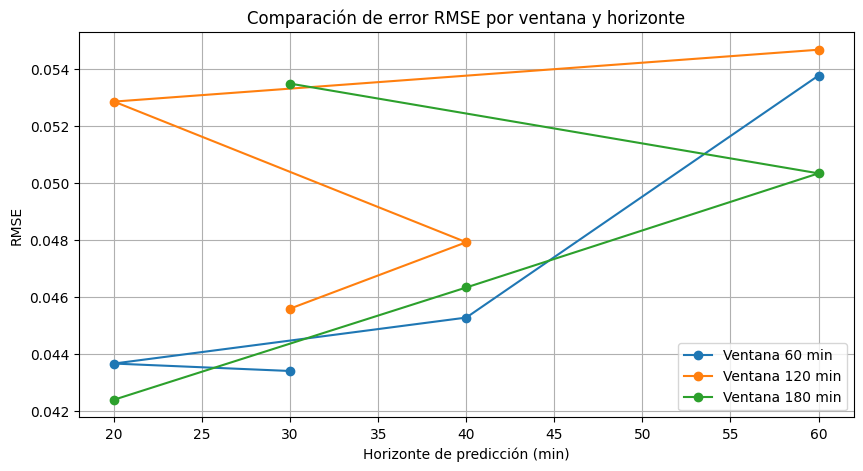


💾 Resultados guardados en 'resultados_LSTM_experimentos.csv'


In [101]:
# ====================================================
# 🔹 IMPORTACIÓN DE LIBRERÍAS
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow.keras.backend as K
import time

# ====================================================
# 🔹 CONFIGURACIÓN GLOBAL
# ====================================================
data = df.copy()
#data = data.drop(columns=["Cintilacion", "Fecha", "Azimuth", "Elevacion"])
data = data.drop(columns=["Cintilacion", "Azimuth", "Elevacion"])

data["Tiempo"] = pd.to_datetime(data["Tiempo"])
data.set_index("Tiempo", inplace=True)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
df_scaled = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)

target_index = data.columns.get_loc("S4")

# ====================================================
# 🔹 FUNCIONES AUXILIARES
# ====================================================

def create_sequences(data, n_steps, horizon, index=None):
    X, y, times = [], [], []
    for i in range(len(data) - n_steps - horizon):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps+horizon, -1])
        if index is not None:
            times.append(index[i+n_steps+horizon])
    return np.array(X), np.array(y), np.array(times)


def peak_loss(y_true, y_pred):
    error = K.abs(y_true - y_pred)
    weight = K.cast(y_true > 0.5, "float32") * 3.0 + 1.0
    return K.mean(weight * error)


def train_lstm(df_scaled, n_steps, horizon, epochs=5, batch_size=32):
    X, y, times = create_sequences(df_scaled.values, n_steps, horizon, df_scaled.index)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    time_train, time_test = times[:split], times[split:]

    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(n_steps, df_scaled.shape[1])),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss=peak_loss)
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)

    y_pred = model.predict(X_test)

    # Invertir escala solo para S4
    s4_scaler = MinMaxScaler()
    s4_scaler.min_, s4_scaler.scale_ = scaler.min_[target_index], scaler.scale_[target_index]
    y_test_original = y_test * s4_scaler.scale_ + s4_scaler.min_
    y_pred_original = y_pred * s4_scaler.scale_ + s4_scaler.min_

    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

    return mae, rmse, mape, y_test_original, y_pred_original


# ====================================================
# 🔹 EXPERIMENTOS AUTOMÁTICOS
# ====================================================

ventanas = [60, 120, 180]       # minutos pasados (1h, 2h, 3h)
horizontes = [20, 30, 40, 60]   # minutos futuros
resultados = []

start = time.time()
for n_steps in ventanas:
    for horizon in horizontes:
        print(f"\n🚀 Entrenando modelo (Ventana={n_steps}, Horizonte={horizon})...")
        mae, rmse, mape, y_real, y_pred = train_lstm(df_scaled, n_steps, horizon, epochs=5)
        resultados.append({
            "Ventana (min)": n_steps,
            "Horizonte (min)": horizon,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })
end = time.time()

print(f"\n⏱️ Tiempo total de experimentación: {(end - start)/60:.2f} minutos")

# ====================================================
# 🔹 ANÁLISIS DE RESULTADOS
# ====================================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="RMSE", ascending=True)
print("\n📊 Resultados comparativos:")
print(df_resultados)

# ====================================================
# 🔹 VISUALIZACIÓN DE RENDIMIENTO
# ====================================================
plt.figure(figsize=(10, 5))
for n_steps in ventanas:
    subset = df_resultados[df_resultados["Ventana (min)"] == n_steps]
    plt.plot(subset["Horizonte (min)"], subset["RMSE"], marker="o", label=f"Ventana {n_steps} min")

plt.title("Comparación de error RMSE por ventana y horizonte")
plt.xlabel("Horizonte de predicción (min)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

# ====================================================
# 🔹 EXPORTAR RESULTADOS
# ====================================================
df_resultados.to_csv("resultados_LSTM_experimentos.csv", index=False)
print("\n💾 Resultados guardados en 'resultados_LSTM_experimentos.csv'")


# **RESULTADOS**

Los resultados **comparativos de la ultima celda** se presentan de forma ordenada de menor a mayor indicando lo siguiente:

**1. El mejor resultado absoluto fue:**

    * Ventana de 180 minutos -Horizonte de 20 minutos
      - MAE = 0.024383
      - RMSE = 0.042404
      - MAPE = 7.66 %
    
    * El modelo predice mejor cuando mira 3 horas hacia atrás y solo **predice 20 minutos al futuro**.
    
    Esto tiene coherencia física:
    * Una ventana grande -> más contexto temporal -> mejor captura de patrones lentos del S4.
    * Horizonte Corto- > más predecible -> menor error.
    
    Esto es lo esperado en series variables o caóticas como S4.

**2. Los segundos mejores resultados estan con:**
    * Ventana de 60 min -  Horizonte 20 o 30 min 
    MAE= 0.0251-0.0253

    * Con solo 1 hora de ventan, el modelo aun rinde casi igual que usando 3 horas.
    * Esto es bueno -> quiere decir que la señal S4 tiene patrones de corta memoria relevantes.

**3. Peor Rendimiento consistentemente:**

    ->  Horizontes largos(60 min)
    ->  Ventanas medianas(120 min)
    Ejemplos:
        - MAE: 0.031
        - RMSE: 0.054



# **Conclusión realista**

* A los 60 minutos el sistema empieza a volverse impredecible.** La ionósfera presenta estocasticidad significativa en esa escala.
    - Las variaciones no siguen patrones regulares identificables.
    - La prediccion tiene un limite natural: por mas modelo o arquitectura que uses, el error no podrá bajar de cierto piso,porque parte del comportamiento es aleatorio.
* Las ventanas grandes (180 min) sí ayudan, pero solo para horizontes cortos (20 min). El mejor caso lo confirma.

* Para horizontes mayores (>40 min), aumentar ventana NO mejora. Porque ya no hay relación temporal fuerte → el sistema es caótico.

* 60 minutos es un “sweet spot” eficiente. Resultados casi iguales a 180 minutos→ con mucho menor costo computacional.

* Los errores están dentro de valores realistas para series S4. MAPEs entre 5% y 9% para horizontes de 20–60 minutos están en línea con la literatura.


# **¿Qué ventana y horizonte  usar en los experimentos finales?**
    
    Depende del objetivo:
    
    ✔ Si se quiere máxima precisión:
    
    Ventana = 180 min
    Horizonte = 20 min
    
    ✔ Si quiere equilibrio entre costo y precisión:
    
    Ventana = 60 min
    Horizonte = 20–30 min
    
    ✔ Si quieres probar predicción agresiva (difícil):
    
    Horizonte = 60 min, pero no podemos esperar buena precisión.
